In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append("..")
sys.path.append("../scripts")
from scripts.paths import raw_data_path, clean_data_path, visualization_dir
from scripts.loader import load_data
from scripts.cleaner import inspect_data, clean_data

In [2]:
raw_df = load_data(raw_data_path)

===== Data Loaded Sucessfully =====


In [3]:
# Inspect raw data
inspect_data(raw_df)


===== Shape =====
(10000, 12)

===== Data Types =====
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  

In [4]:
df = clean_data(raw_df)
# inspect clean data
inspect_data(df)


===== Shape =====
(10000, 12)

===== Data Types =====
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  

#### This plot shows the number of customers who churned (1) and those didnot (0), providing a quick view of the target variable

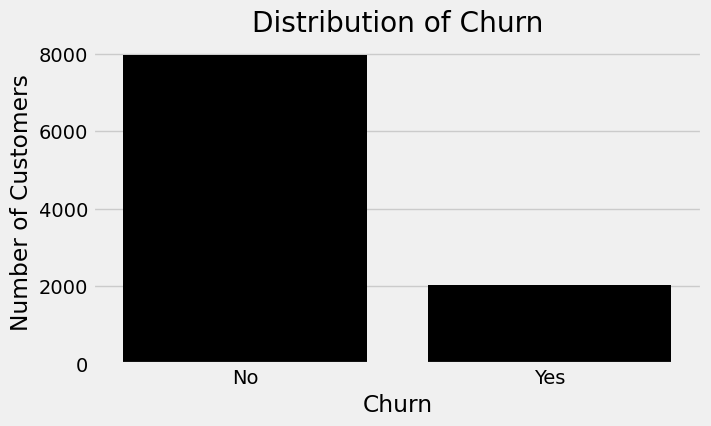

In [6]:
plt.style.use('fivethirtyeight')
plt.figure(figsize = (7,4))
sns.countplot(data = df, x = 'churn', color = 'black')
plt.xticks([0, 1], ["No", "Yes"])
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
file_path = os.path.join(visualization_dir, 'churn_distribution.png')
plt.savefig(file_path, bbox_inches="tight")
plt.show()

#### This calculates the percentage of customers who churned and those who reamained, showing the proportion of each class in the dataset

In [8]:
print(df['churn'].value_counts(normalize = True)* 100)

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


#### Separating numerical and categorical featutes while excluding the Customer ID and target variable from feature analysis

In [10]:
cat_cols = df.select_dtypes(include =['object']).columns
num_cols = df.select_dtypes(include =['number']).columns
num_cols = num_cols.drop(['customer_id','churn'])
print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: Index(['country', 'gender'], dtype='object')
Numerical Columns: Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')


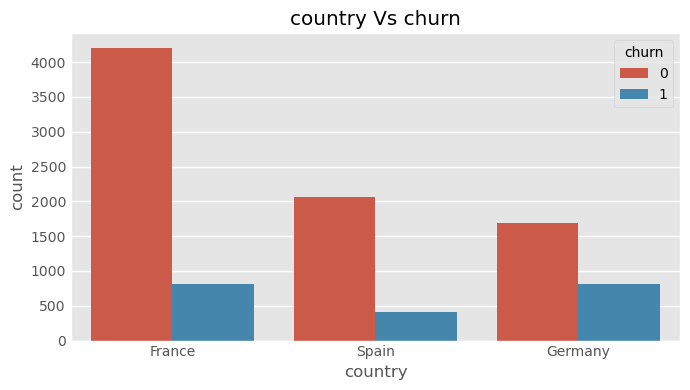

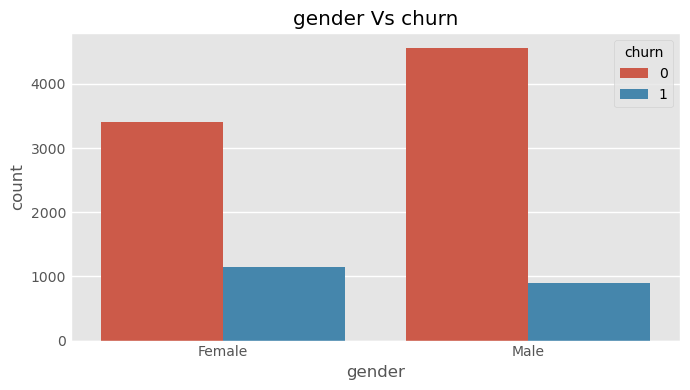

In [11]:
for col in cat_cols:
    plt.style.use('ggplot')
    plt.figure(figsize = (7,4))
    sns.countplot(data = df, x = col, hue ='churn')
    plt.title(f"{col} Vs churn")
    plt.tight_layout()
    file_path = os.path.join(visualization_dir, f"{col}_vs_churn.png")
    plt.savefig(file_path, bbox_inches = "tight")
    plt.show()
    plt.close()

#### Calculates the percentage of customers who churned within each category. This helps identify which customer groups have higher churn rates

In [13]:
for col in cat_cols:
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending = False)* 100
    print(f"\n===== {col} =====")
    print(churn_rate)


===== country =====
country
Germany    32.443204
Spain      16.673395
France     16.154767
Name: churn, dtype: float64

===== gender =====
gender
Female    25.071539
Male      16.455928
Name: churn, dtype: float64


In [14]:
cols = [ "credit_card","active_member","products_number","tenure"]

for col in cols:
    churn_rate = (df.groupby(col)["churn"].mean().sort_values(ascending=False) * 100).round(2)
    print(f"\n===== {col} =====")
    print(churn_rate)


===== credit_card =====
credit_card
0    20.81
1    20.18
Name: churn, dtype: float64

===== active_member =====
active_member
0    26.85
1    14.27
Name: churn, dtype: float64

===== products_number =====
products_number
4    100.00
3     82.71
1     27.71
2      7.58
Name: churn, dtype: float64

===== tenure =====
tenure
0     23.00
1     22.42
9     21.65
3     21.11
5     20.65
10    20.61
4     20.53
6     20.27
8     19.22
2     19.18
7     17.22
Name: churn, dtype: float64


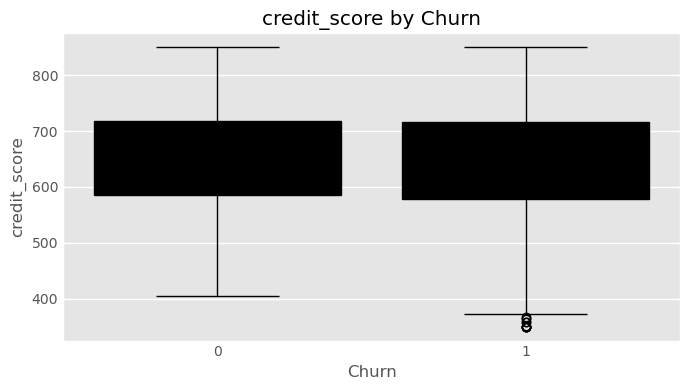

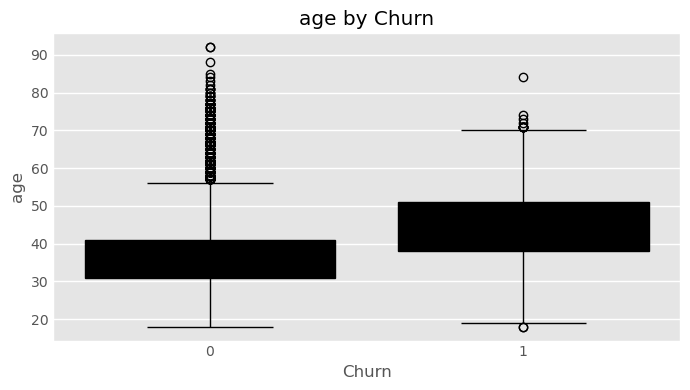

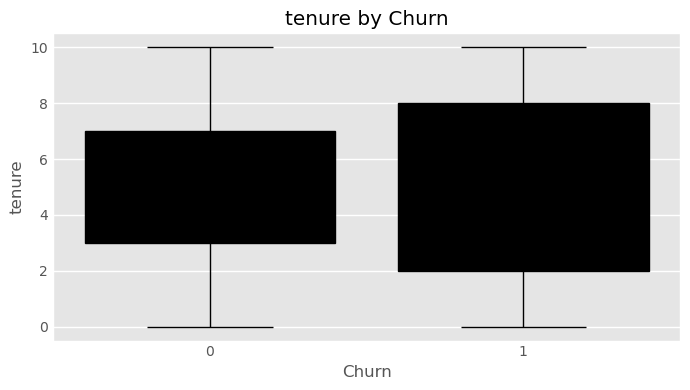

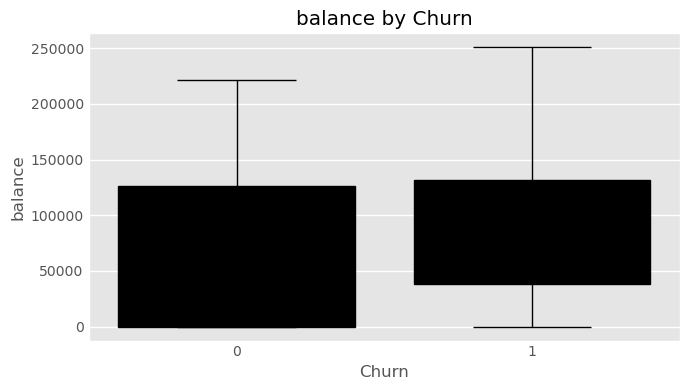

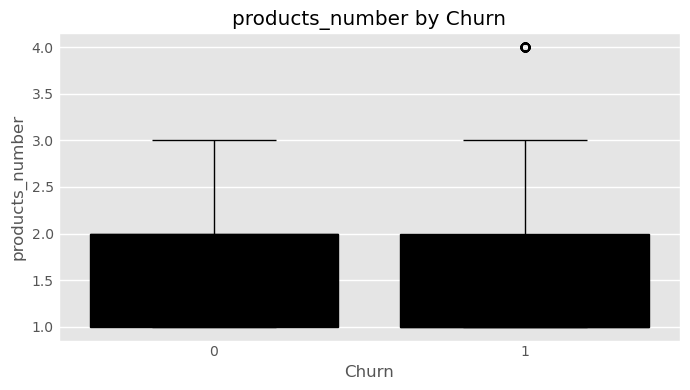

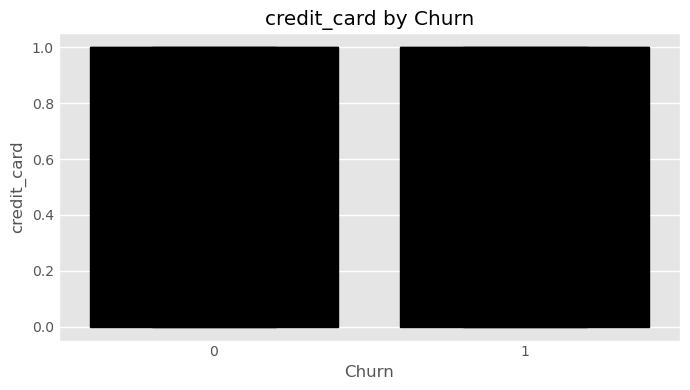

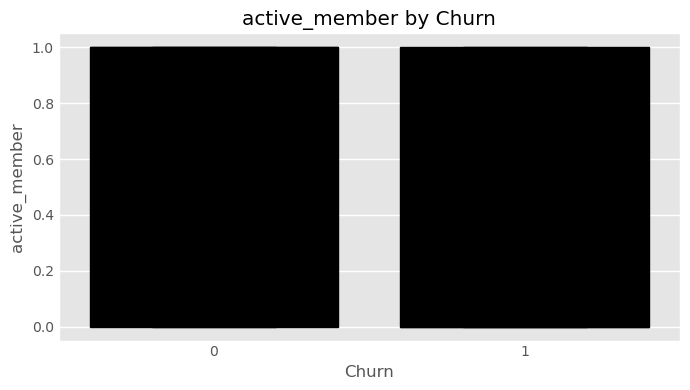

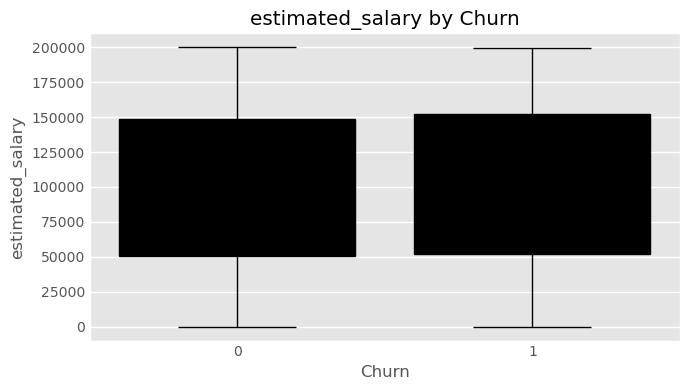

In [15]:
for col in num_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df,x="churn",y=col, color = 'black')
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.tight_layout()

    file_path = os.path.join(visualization_dir,f"{col}_by_churn.png")

    plt.savefig(file_path, bbox_inches="tight")
    plt.show()
    plt.close()

#### These histograms show the distribution of numerical features and help identify skewness, concentration, and unusual values.

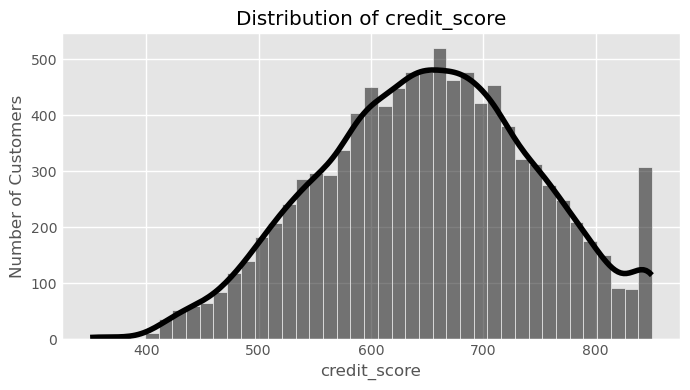

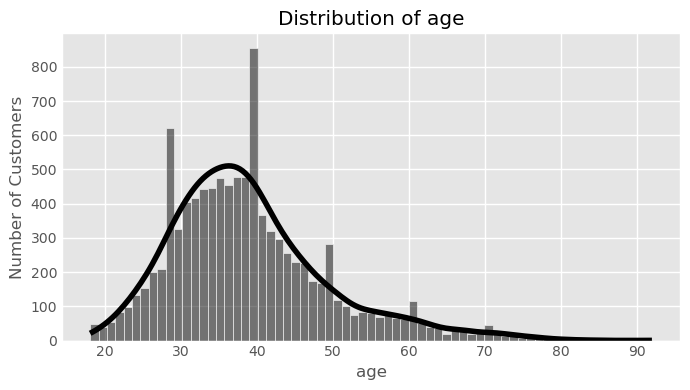

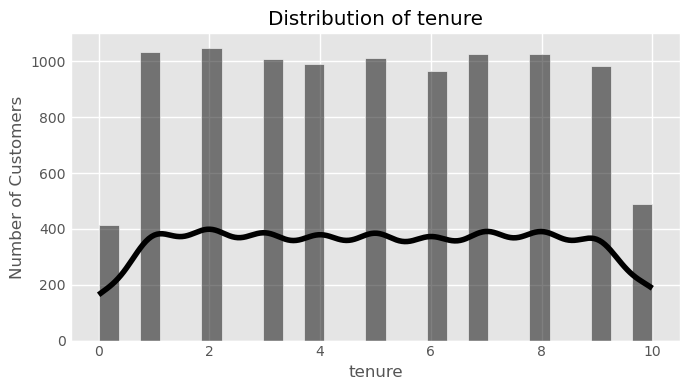

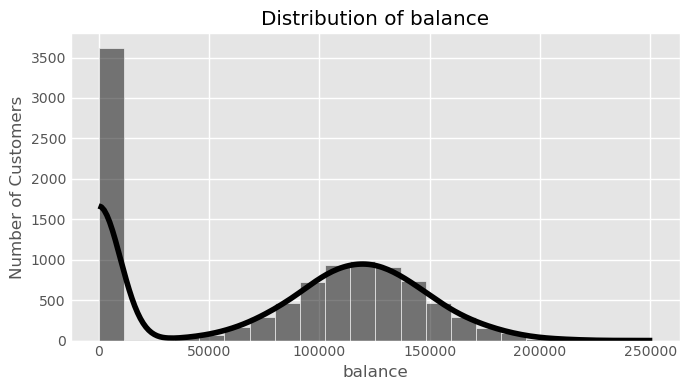

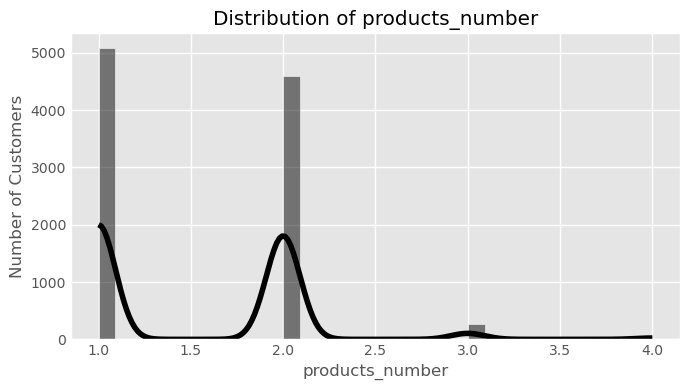

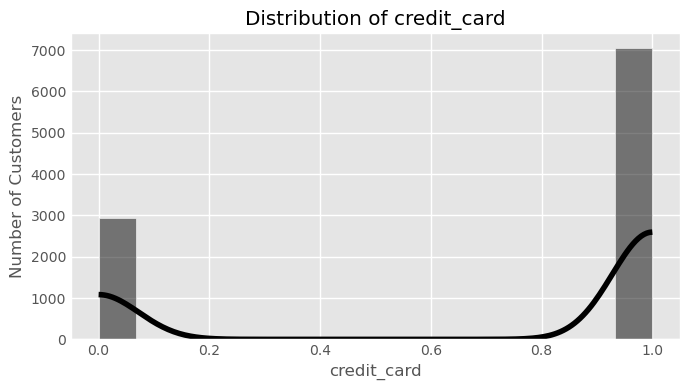

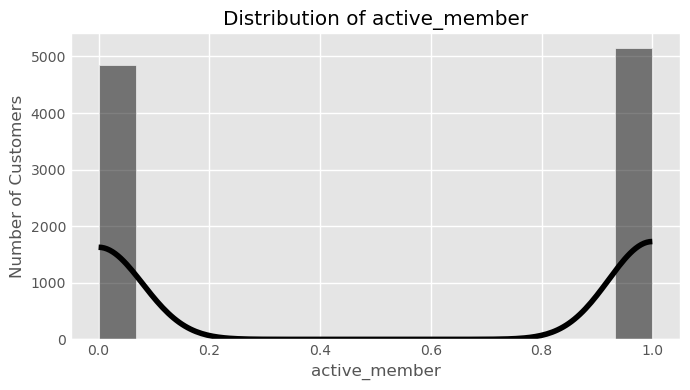

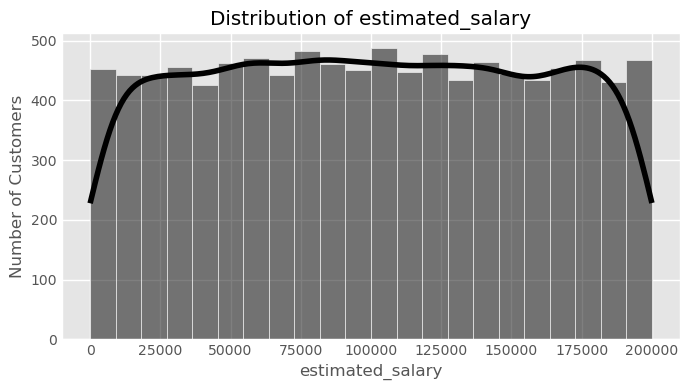

In [17]:
for col in num_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(data=df,x=col,kde=True,color="black")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.tight_layout()

    file_path = os.path.join(visualization_dir,f"{col}_distribution.png")

    plt.savefig(file_path, bbox_inches="tight")
    plt.show()
    plt.close()

####  Correlation analysis examines relationships between numerical variables and the churn target to identify potentially relevant patterns.

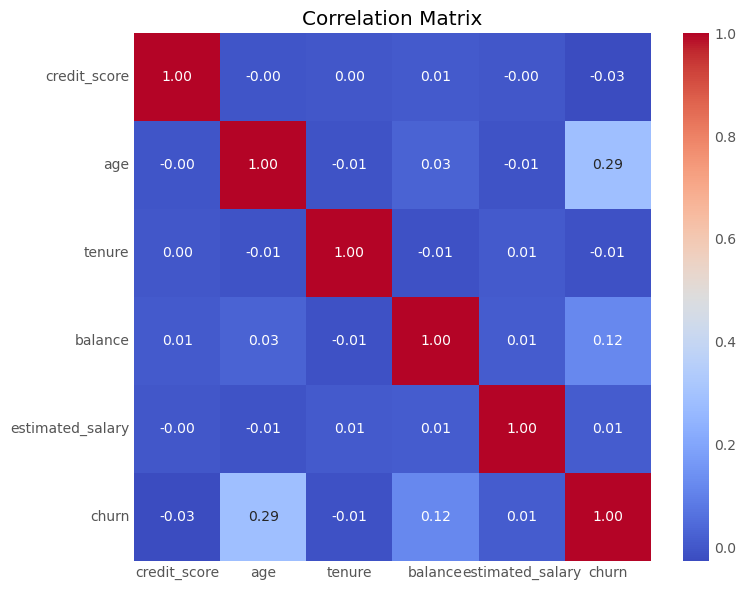

In [19]:
corr_cols = ["credit_score","age","tenure","balance","estimated_salary","churn"]
corr = df[corr_cols].corr()
plt.figure(figsize=(8, 6))

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Matrix")
plt.tight_layout()

file_path = os.path.join(visualization_dir,"correlation_matrix.png")

plt.savefig(file_path, bbox_inches="tight")
plt.show()
plt.close()